# B2B Multi-Group Analysis (1400M/3600M/4900M × M=2,3,5,13,15)

处理19个B2B文件，按频段和M值分组，对比统计和可视化。

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from datetime import datetime
import warnings

PROJECT_ROOT = Path().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.io.bin_read import (
    _load_frames, _parse_iq, BW_HZ, U, _S_MATCHED, _N_FFT,
    FRAME_LEN, FS_HZ,
)
from src.io.b2b_extract import diagnose_b2b_delay
from src.paths import RAW_CALI_DIR
import src.io.bin_read as _bin_read_mod

matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 12
%matplotlib inline

print(f"Project root: {PROJECT_ROOT}")
print(f"FRAME_LEN={FRAME_LEN}, U={U}, FS_HZ={FS_HZ/1e6:.0f} MHz, BW={BW_HZ/1e6:.0f} MHz")

Project root: /home/guo/桌面/project/chan_meas
FRAME_LEN=4132, U=1024, FS_HZ=100 MHz, BW=50 MHz


## Section 2: Select and List B2B Files

In [2]:
b2b_files = sorted(RAW_CALI_DIR.rglob('*.bin'))
print(f"B2B .bin files ({len(b2b_files)} found):")
for i, f in enumerate(b2b_files):
    size_mb = f.stat().st_size / 1e6
    rel = f.relative_to(RAW_CALI_DIR)
    print(f"  [{i:2d}] {str(rel):70s}  ({size_mb:6.1f} MB)")

B2B .bin files (19 found):
  [ 0] 20260402_cfo_mea/CFO_B2B_20260407_M13_Black01_081cable_1400M.bin        ( 129.7 MB)
  [ 1] 20260402_cfo_mea/CFO_B2B_20260407_M13_Black01_081cable_3600M.bin        ( 128.2 MB)
  [ 2] 20260402_cfo_mea/CFO_B2B_20260407_M13_Black01_081cable_4900M.bin        ( 131.0 MB)
  [ 3] 20260402_cfo_mea/CFO_B2B_20260407_M2_Black01_081cable_1400M.bin         ( 152.2 MB)
  [ 4] 20260402_cfo_mea/CFO_B2B_20260407_M2_Black01_081cable_3600M.bin         ( 138.9 MB)
  [ 5] 20260402_cfo_mea/CFO_B2B_20260407_M2_Black01_081cable_4900M.bin         ( 127.9 MB)
  [ 6] 20260402_cfo_mea/CFO_B2B_20260407_M3_Black01_081cable_1400M.bin         ( 153.5 MB)
  [ 7] 20260402_cfo_mea/CFO_B2B_20260407_M3_Black01_081cable_3600M.bin         ( 133.6 MB)
  [ 8] 20260402_cfo_mea/CFO_B2B_20260407_M3_Black01_081cable_4900M.bin         ( 130.2 MB)
  [ 9] 20260402_cfo_mea/CFO_B2B_20260407_M5_Black01_081cable_1400M.bin         ( 145.9 MB)
  [10] 20260402_cfo_mea/CFO_B2B_20260407_M5_Black01_081cable_36

## Section 3: Frequency Group Definitions

In [3]:
# 按频段和M值分组
FREQ_GROUPS = {
    '1400M': {'M2': 3, 'M3': 6, 'M5': 9, 'M13': 0, 'M15': 13},
    '3600M': {'M2': 4, 'M3': 7, 'M5': 10, 'M13': 1, 'M15': 14},
    '4900M': {'M2': 5, 'M3': 8, 'M5': 11, 'M13': 2, 'M15': 15},
}
M_ORDER = ['M2', 'M3', 'M5', 'M13', 'M15']

print("分组定义：")
for freq, m_dict in FREQ_GROUPS.items():
    indices = [m_dict[m] for m in M_ORDER]
    print(f"  {freq}: {indices}")

分组定义：
  1400M: [3, 6, 9, 0, 13]
  3600M: [4, 7, 10, 1, 14]
  4900M: [5, 8, 11, 2, 15]


## Section 4: GPU Acceleration & Processing Functions

In [4]:
# CPU 版本（作为 fallback）
def _sliding_correlate_cpu(iq: np.ndarray) -> np.ndarray:
    x = iq - iq.mean(axis=1, keepdims=True)
    ext = np.tile(x, (1, 3))
    S_f = np.fft.fft(_S_MATCHED, n=_N_FFT)
    F = np.fft.fft(ext, n=_N_FFT, axis=1) * S_f
    corr = np.fft.ifft(F, axis=1)
    return (corr[:, 2 * U - 1 : 3 * U - 1] / U).astype(np.complex64)

# 尝试启用 cupy GPU 加速
try:
    import cupy as cp
    
    def _sliding_correlate_gpu(iq: np.ndarray) -> np.ndarray:
        iq_gpu = cp.asarray(iq, dtype=cp.complex64)
        x = iq_gpu - iq_gpu.mean(axis=1, keepdims=True)
        ext = cp.tile(x, (1, 3))
        S_f = cp.fft.fft(cp.asarray(_S_MATCHED, dtype=cp.complex64), n=_N_FFT)
        F = cp.fft.fft(ext, n=_N_FFT, axis=1) * S_f
        corr = cp.fft.ifft(F, axis=1)
        result = (corr[:, 2 * U - 1 : 3 * U - 1] / U).astype(cp.complex64)
        return cp.asnumpy(result)
    
    _sliding_correlate_fast = _sliding_correlate_gpu
    _bin_read_mod._sliding_correlate = _sliding_correlate_gpu
    use_gpu = True
    print("✅ GPU (cupy) 加速已启用")
except ImportError:
    _sliding_correlate_fast = _sliding_correlate_cpu
    _bin_read_mod._sliding_correlate = _sliding_correlate_cpu
    use_gpu = False
    print("⚠️ cupy 未安装，使用 CPU numpy FFT")

⚠️ cupy 未安装，使用 CPU numpy FFT


In [5]:
def process_one_file(b2b_path):
    """处理单个B2B文件，返回诊断结果."""
    frames = _load_frames(b2b_path)
    iq = _parse_iq(frames)
    del frames
    
    cir_b2b = _sliding_correlate_fast(iq)
    del iq
    n_frames = cir_b2b.shape[0]
    
    # 硬件延迟诊断
    diag = diagnose_b2b_delay(cir_b2b)
    
    # 逐帧 peak delay 统计
    peak_bins_per_frame = np.argmax(np.abs(cir_b2b), axis=1)
    peak_delay_per_frame_ns = peak_bins_per_frame * (1e9 / BW_HZ)
    delay_min_ns = peak_delay_per_frame_ns.min()
    delay_max_ns = peak_delay_per_frame_ns.max()
    delay_span_ns = delay_max_ns - delay_min_ns
    
    # CFO 估计（frame-to-frame phase drift）
    frame_indices = np.arange(n_frames)
    cir_at_peak = cir_b2b[frame_indices, peak_bins_per_frame]
    phase_unwrapped = np.unwrap(np.angle(cir_at_peak))
    phase_drift = np.diff(phase_unwrapped)
    
    # 去除异常值（MAD）
    median_drift = np.median(phase_drift)
    mad = np.median(np.abs(phase_drift - median_drift))
    outlier_mask = np.abs(phase_drift - median_drift) > 5 * mad
    drift_clean = phase_drift.copy()
    drift_clean[outlier_mask] = median_drift
    
    T_frame_s = FRAME_LEN / FS_HZ
    cfo_est_hz = drift_clean.mean() / (2 * np.pi * T_frame_s)
    n_outliers = int(outlier_mask.sum())
    
    return {
        'cir_b2b': cir_b2b,
        'n_frames': n_frames,
        'diag': diag,
        'peak_bins': peak_bins_per_frame,
        'delay_min_ns': delay_min_ns,
        'delay_max_ns': delay_max_ns,
        'delay_span_ns': delay_span_ns,
        'drift_clean': drift_clean,
        'cfo_est_hz': cfo_est_hz,
        'n_outliers': n_outliers,
    }

print(f"处理函数定义完成 (GPU={use_gpu})")

处理函数定义完成 (GPU=False)


## Section 5: Batch Processing All Files

In [6]:
results = {}
start_time = datetime.now()

for freq, m_dict in FREQ_GROUPS.items():
    results[freq] = {}
    for m_val in M_ORDER:
        idx = m_dict[m_val]
        b2b_path = b2b_files[idx]
        rel_path = b2b_path.relative_to(RAW_CALI_DIR)
        print(f"\n⏳ [{freq}/{m_val}] {rel_path.name}...", end=' ', flush=True)
        
        try:
            result = process_one_file(b2b_path)
            results[freq][m_val] = result
            print(f"✅  {result['n_frames']} frames")
        except Exception as e:
            print(f"❌ {e}")
            results[freq][m_val] = None

elapsed = (datetime.now() - start_time).total_seconds()
print(f"\n✅ 处理完成  耗时: {elapsed:.1f}s")


⏳ [1400M/M2] CFO_B2B_20260407_M2_Black01_081cable_1400M.bin... ✅  36829 frames

⏳ [1400M/M3] CFO_B2B_20260407_M3_Black01_081cable_1400M.bin... ✅  37148 frames

⏳ [1400M/M5] CFO_B2B_20260407_M5_Black01_081cable_1400M.bin... ✅  35318 frames

⏳ [1400M/M13] CFO_B2B_20260407_M13_Black01_081cable_1400M.bin... ✅  31396 frames

⏳ [1400M/M15] Calib_V1_20260402_B2B_Black01_081cable_1400M_40dB.bin... ✅  31188 frames

⏳ [3600M/M2] CFO_B2B_20260407_M2_Black01_081cable_3600M.bin... ✅  33625 frames

⏳ [3600M/M3] CFO_B2B_20260407_M3_Black01_081cable_3600M.bin... ✅  32334 frames

⏳ [3600M/M5] CFO_B2B_20260407_M5_Black01_081cable_3600M.bin... ✅  30483 frames

⏳ [3600M/M13] CFO_B2B_20260407_M13_Black01_081cable_3600M.bin... ✅  31018 frames

⏳ [3600M/M15] Calib_V1_20260402_B2B_Black01_081cable_3600M_40dB.bin... ✅  32618 frames

⏳ [4900M/M2] CFO_B2B_20260407_M2_Black01_081cable_4900M.bin... ✅  30963 frames

⏳ [4900M/M3] CFO_B2B_20260407_M3_Black01_081cable_4900M.bin... ✅  31517 frames

⏳ [4900M/M5] CFO_B2

## Section 6: Per-Frame Peak Delay Statistics Table

In [7]:
print("Per-Frame Peak Delay Statistics (ns)\n")
print(f"{'Freq':>8} | " + " | ".join(f"{m:>12}" for m in M_ORDER))
print("-" * 85)

for freq in ['1400M', '3600M', '4900M']:
    min_vals = []
    max_vals = []
    span_vals = []
    
    for m_val in M_ORDER:
        res = results[freq].get(m_val)
        if res:
            min_vals.append(f"{res['delay_min_ns']:.0f}")
            max_vals.append(f"{res['delay_max_ns']:.0f}")
            span_vals.append(f"{res['delay_span_ns']:.0f}")
        else:
            min_vals.append("---")
            max_vals.append("---")
            span_vals.append("---")
    
    print(f"{freq:>8} | " + " | ".join(f"{v:>12}" for v in min_vals) + "  (min)")
    print(f"{'':>8} | " + " | ".join(f"{v:>12}" for v in max_vals) + "  (max)")
    print(f"{'':>8} | " + " | ".join(f"{v:>12}" for v in span_vals) + "  (span)")
    print()

Per-Frame Peak Delay Statistics (ns)

    Freq |           M2 |           M3 |           M5 |          M13 |          M15
-------------------------------------------------------------------------------------
   1400M |         1460 |         1460 |         1440 |         1460 |         1280  (min)
         |         1500 |         1520 |         1500 |         1500 |         1380  (max)
         |           40 |           60 |           60 |           40 |          100  (span)

   3600M |         1460 |         1460 |         1460 |         1440 |         1400  (min)
         |         1520 |         1500 |         1500 |         1480 |         1500  (max)
         |           60 |           40 |           40 |           40 |          100  (span)

   4900M |         1460 |         1440 |         1460 |         1460 |         1320  (min)
         |         1500 |         1480 |         1500 |         1500 |         1400  (max)
         |           40 |           40 |           40 |     

## Section 7: PDP Comparison (Frame 100)

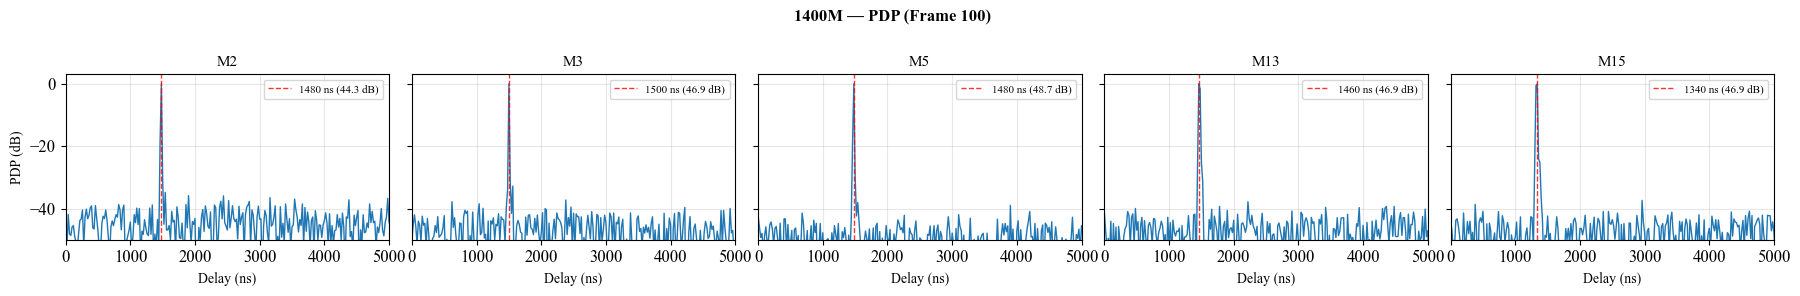

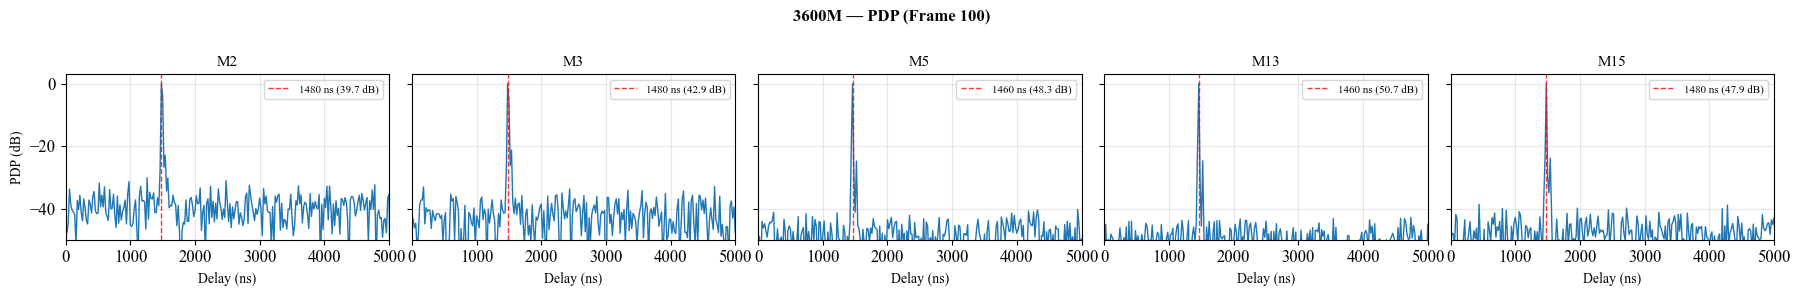

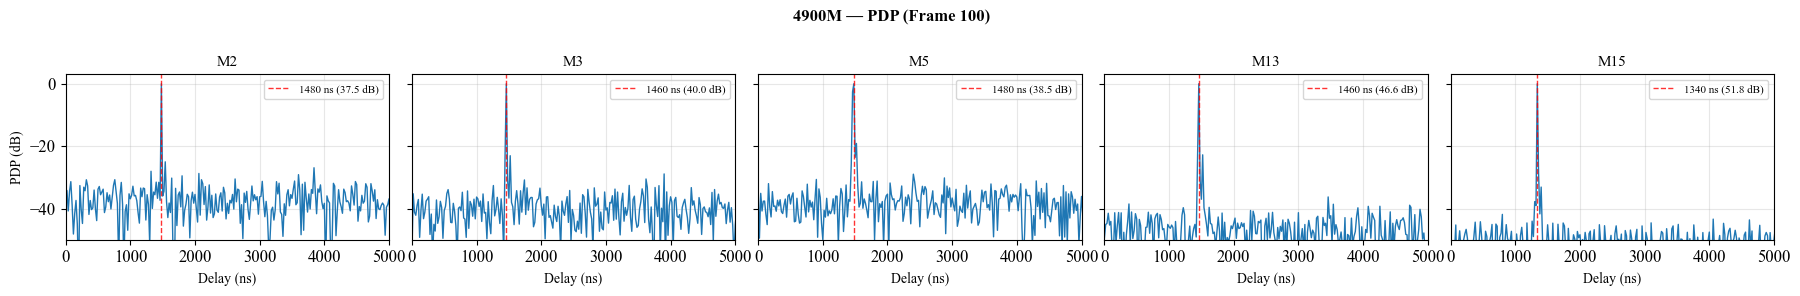

In [8]:
delay_ns = np.arange(U) / BW_HZ * 1e9
num = 100  # 第100帧

def single_frame_diag(cir_frame):
    """单帧CIR的peak诊断."""
    pdp = np.abs(cir_frame)**2
    peak_bin = np.argmax(pdp)
    peak_delay_ns = peak_bin * 1e9 / BW_HZ
    # 噪声地板：距离peak > 50个样点的中位数
    mask = np.abs(np.arange(len(pdp)) - peak_bin) > 50
    noise_floor = np.median(pdp[mask]) if mask.sum() > 10 else pdp.min()
    peak_power_db = 10 * np.log10(pdp[peak_bin] / max(noise_floor, 1e-30))
    return peak_bin, peak_delay_ns, peak_power_db

for freq in ['1400M', '3600M', '4900M']:
    fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=True)
    
    for ax, m_val in zip(axes, M_ORDER):
        res = results[freq].get(m_val)
        if not res:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_title(m_val)
            continue
        
        cir = res['cir_b2b']
        if num >= cir.shape[0]:
            ax.text(0.5, 0.5, f'Frame {num} out of range', ha='center', va='center')
            ax.set_title(m_val)
            continue
        
        pdp = np.abs(cir[num])**2
        pdp_db = 10 * np.log10(pdp + 1e-30)
        pdp_db -= pdp_db.max()
        
        peak_bin, peak_delay, peak_pow = single_frame_diag(cir[num])
        
        ax.plot(delay_ns, pdp_db, lw=1)
        ax.axvline(peak_delay, color='r', ls='--', lw=1, alpha=0.8,
                   label=f"{peak_delay:.0f} ns ({peak_pow:.1f} dB)")
        ax.set_xlabel('Delay (ns)', fontsize=10)
        ax.set_ylabel('PDP (dB)', fontsize=10) if ax == axes[0] else None
        ax.set_title(m_val, fontsize=11)
        ax.set_xlim([0, 5000])
        ax.set_ylim([-50, 3])
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    fig.suptitle(f'{freq} — PDP (Frame {num})', fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()

## Section 8: Peak Power vs Time (Frame-by-Frame)

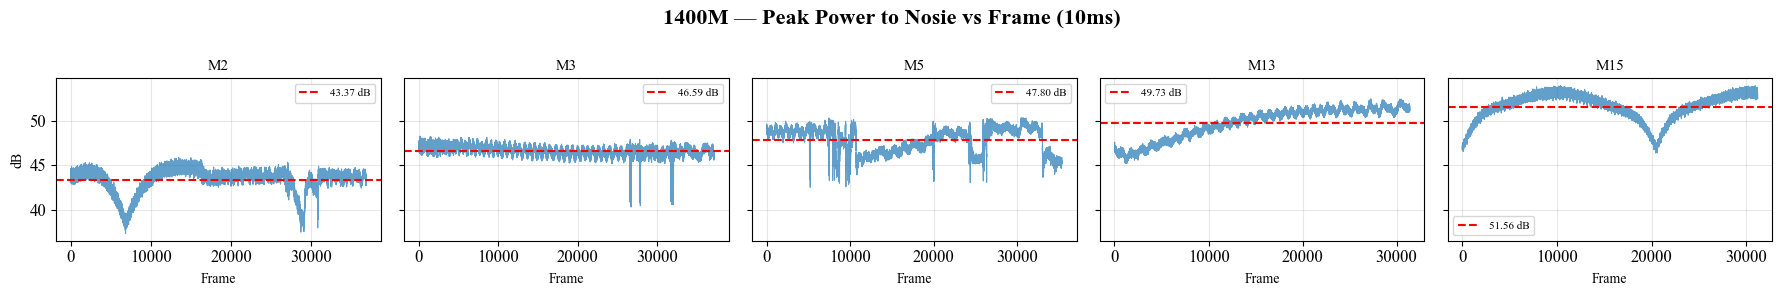

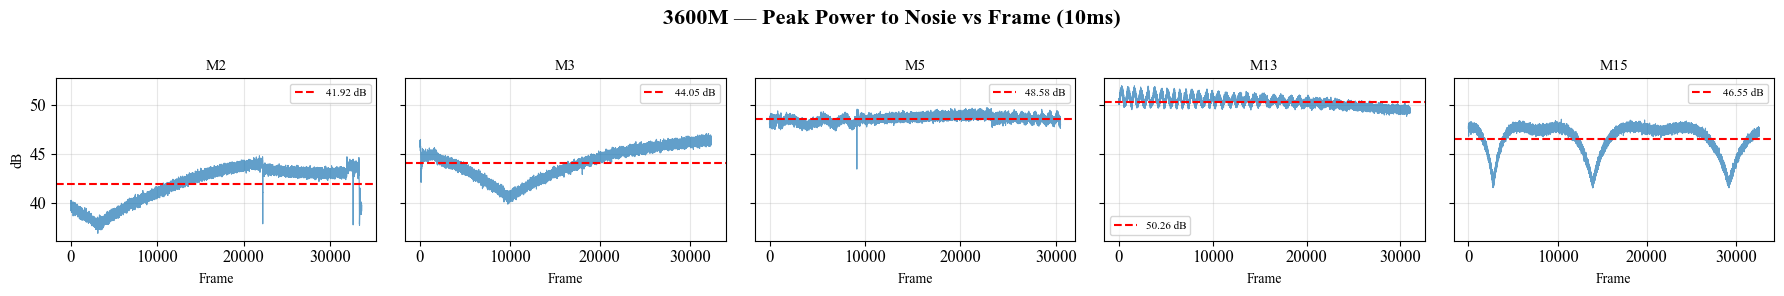

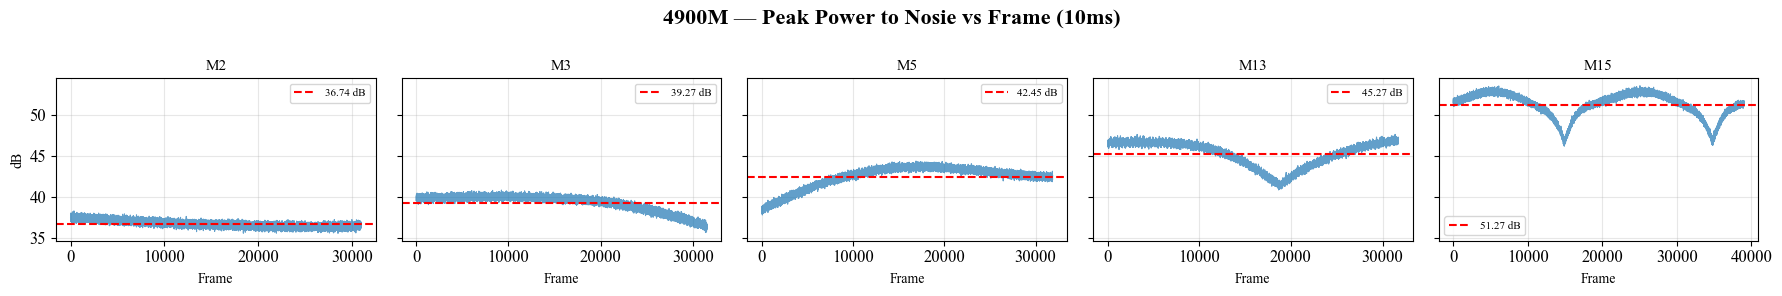

In [9]:
def single_frame_diag(cir_frame):
    """单帧CIR的peak诊断 (与Section 7一致)."""
    pdp = np.abs(cir_frame)**2
    peak_bin = np.argmax(pdp)
    mask = np.abs(np.arange(len(pdp)) - peak_bin) > 50
    noise_floor = np.median(pdp[mask]) if mask.sum() > 10 else pdp.min()
    peak_power_db = 10 * np.log10(pdp[peak_bin] / max(noise_floor, 1e-30))
    return peak_power_db

# 对每个频率绘制 5 个 M 值的 peak power 时间序列
for freq in ['1400M', '3600M', '4900M']:
    fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=True)
    
    for ax, m_val in zip(axes, M_ORDER):
        res = results[freq].get(m_val)
        if res is None:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_title(m_val)
            continue
        
        cir_b2b = res['cir_b2b']
        n_frames = cir_b2b.shape[0]
        
        # 计算每一帧的 peak_power_db
        peak_power_series = np.array([
            single_frame_diag(cir_b2b[i]) for i in range(n_frames)
        ])
        
        # 绘制曲线
        frame_indices = np.arange(n_frames)
        ax.plot(frame_indices, peak_power_series, lw=0.8, alpha=0.7)
        
        # 添加均值线
        mean_power = peak_power_series.mean()
        ax.axhline(mean_power, color='r', ls='--', lw=1.5, alpha=1,
                   label=f'{mean_power:.2f} dB')
        
        ax.set_xlabel('Frame', fontsize=10)
        if ax == axes[0]:
            ax.set_ylabel('dB', fontsize=10)
        ax.set_title(m_val, fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        
        del peak_power_series
    
    fig.suptitle(f'{freq} — Peak Power to Nosie vs Frame (10ms)', fontsize=16, fontweight='bold')
    fig.tight_layout()
    fig.savefig(f'{freq}_peak_power.png', dpi=150, bbox_inches='tight')
    plt.show()

## Section 9: Phase Drift CDF Analysis

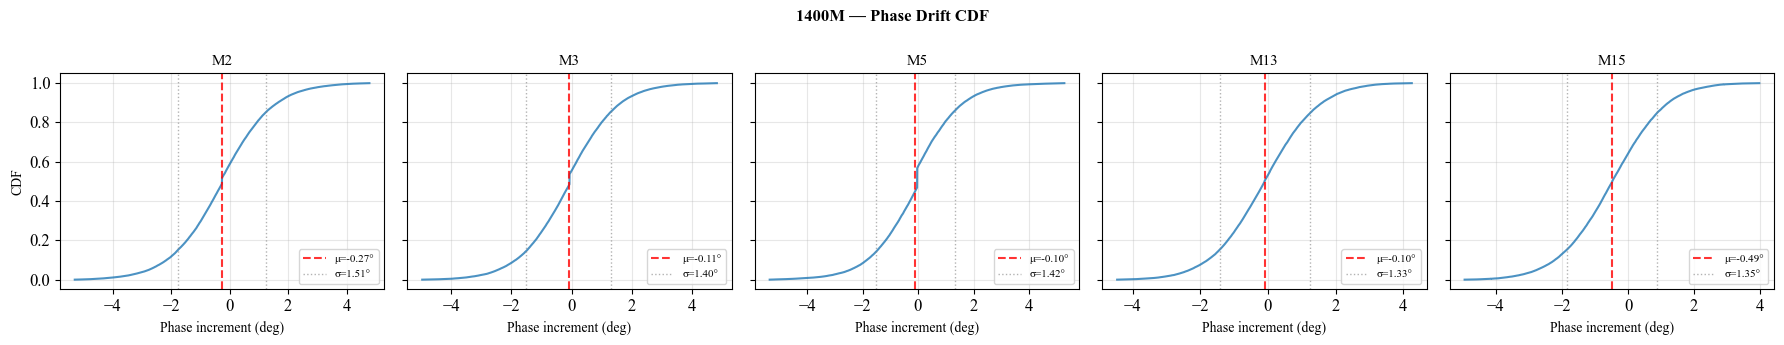

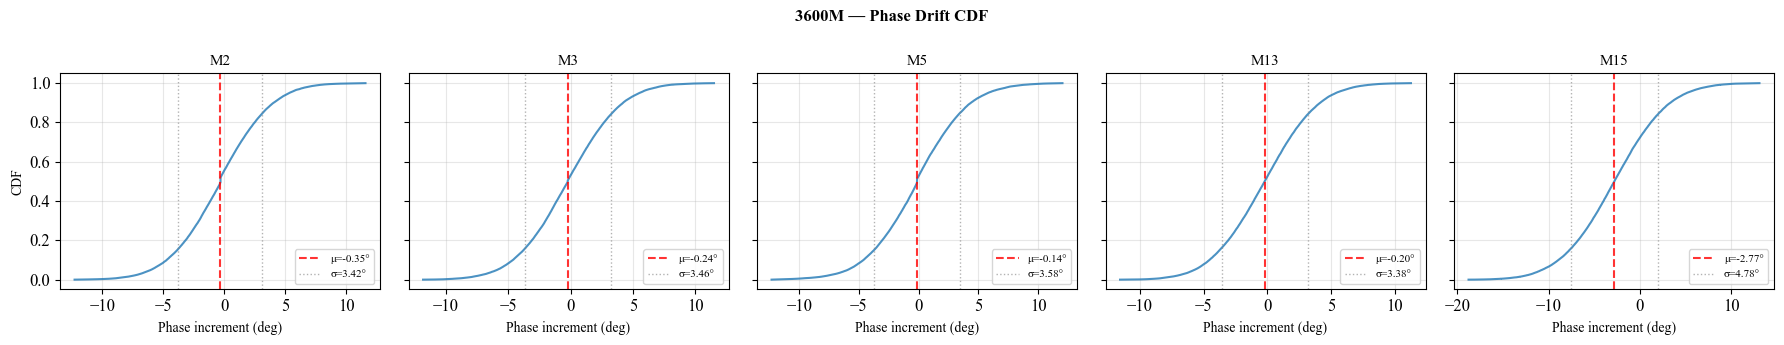

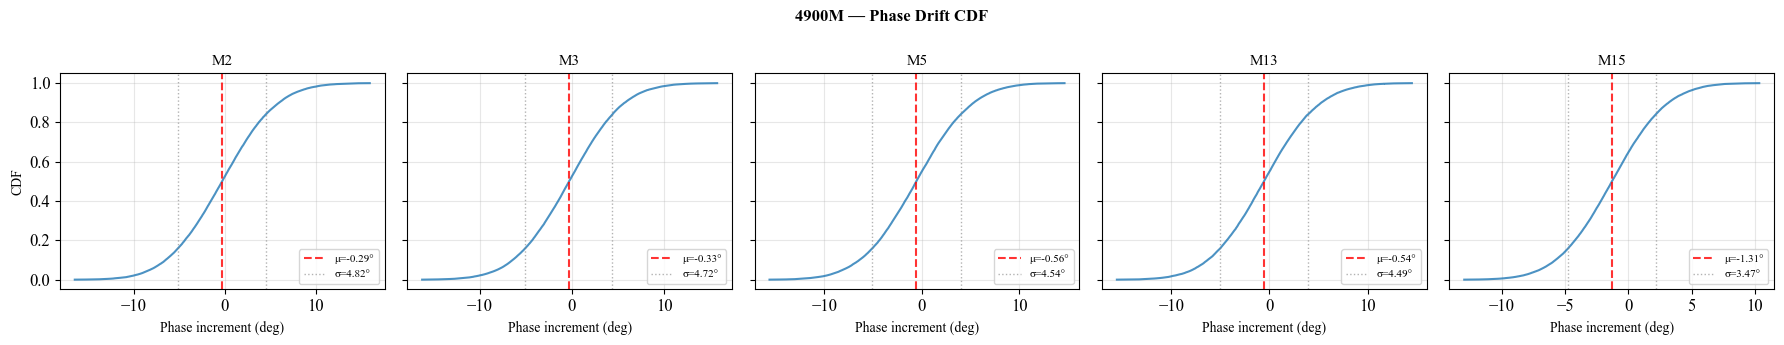

In [10]:
# 对每个频率绘制 5 个 M 值的相位漂移 CDF
for freq in ['1400M', '3600M', '4900M']:
    fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=True)
    
    for ax, m_val in zip(axes, M_ORDER):
        res = results[freq].get(m_val)
        if res is None:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_title(m_val)
            continue
        
        cir_b2b = res['cir_b2b']
        n_frames = cir_b2b.shape[0]
        
        # ── Dynamic Peak Tracking ─────────────────────────────────────────────
        peak_bins_per_frame = np.argmax(np.abs(cir_b2b), axis=1)
        frame_indices = np.arange(n_frames)
        cir_at_dynamic_peak = cir_b2b[frame_indices, peak_bins_per_frame]
        
        phase_at_peak = np.angle(cir_at_dynamic_peak)
        phase_unwrapped = np.unwrap(phase_at_peak)
        phase_drift_per_frame = np.diff(phase_unwrapped)
        
        # ── Outlier removal (MAD-based) ───────────────────────────────────────
        median_drift = np.median(phase_drift_per_frame)
        mad = np.median(np.abs(phase_drift_per_frame - median_drift))
        outlier_mask = np.abs(phase_drift_per_frame - median_drift) > 5 * mad
        
        drift_clean = phase_drift_per_frame.copy()
        drift_clean[outlier_mask] = median_drift
        
        # ── CFO 估计 ─────────────────────────────────────────────────────────
        T_frame_s = FRAME_LEN / FS_HZ
        mean_drift_rad = drift_clean.mean()
        cfo_est_hz = mean_drift_rad / (2 * np.pi * T_frame_s)
        drift_std_rad = drift_clean.std()
        
        # ── CDF ─────────────────────────────────────────────────────────────
        drift_deg = np.rad2deg(drift_clean)
        sorted_drift = np.sort(drift_deg)
        cdf = np.arange(1, len(sorted_drift) + 1) / len(sorted_drift)
        
        # 绘制 CDF 曲线
        ax.plot(sorted_drift, cdf, lw=1.5, alpha=0.8)
        
        # 添加均值线
        mean_deg = np.rad2deg(mean_drift_rad)
        ax.axvline(mean_deg, color='r', ls='--', lw=1.5, alpha=0.8,
                   label=f'μ={mean_deg:.2f}°')
        
        # 添加 ±1σ 线
        std_deg = np.rad2deg(drift_std_rad)
        ax.axvline(mean_deg - std_deg, color='gray', ls=':', lw=1, alpha=0.6)
        ax.axvline(mean_deg + std_deg, color='gray', ls=':', lw=1, alpha=0.6,
                   label=f'σ={std_deg:.2f}°')
        
        ax.set_xlabel('Phase increment (deg)', fontsize=10)
        if ax == axes[0]:
            ax.set_ylabel('CDF', fontsize=10)
        ax.set_title(m_val, fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='lower right')
    
    fig.suptitle(f'{freq} — Phase Drift CDF', fontsize=12, fontweight='bold')
    fig.tight_layout()
    fig.savefig(f'{freq}_CFO.png', dpi=150, bbox_inches='tight')
    plt.show()

## Section 10: Extract H(f) — B2B System Response Calibration

幅度平均 FFT：独立 TCXO 帧间相位随机游走，不可跨帧相干平均，
故取各帧 |FFT(CIR)| 均值，再拼上第 0 帧相位，得到稳定的 H(f) 估计。

输出：`CALIB_B2B_HF_DIR / H_f_{freq}_{m_val}.npy`，shape=(U,)，complex128。

In [11]:
from src.paths import CALIB_B2B_HF_DIR

CALIB_B2B_HF_DIR.mkdir(parents=True, exist_ok=True)

h_f_dict = {}  # {freq: {m_val: np.ndarray (U,) complex128}}

for freq in ['1400M', '3600M', '4900M']:
    h_f_dict[freq] = {}
    for m_val in M_ORDER:
        res = results[freq].get(m_val)
        if res is None:
            print(f'  [{freq}/{m_val}] skip (no data)')
            continue

        cir = res['cir_b2b'].astype(np.complex128)   # (n_frames, U)
        H_frames = np.fft.fft(cir, axis=1)            # (n_frames, U)
        H_mag_avg = np.abs(H_frames).mean(axis=0)     # (U,)
        H_phase_0 = np.angle(H_frames[0])             # (U,)
        h_f = (H_mag_avg * np.exp(1j * H_phase_0)).astype(np.complex128)

        h_f_dict[freq][m_val] = h_f

        out_path = CALIB_B2B_HF_DIR / f'H_f_{freq}_{m_val}.npy'
        np.save(out_path, h_f)
        print(f'  [{freq}/{m_val}] {out_path.name}  shape={h_f.shape}')

n_saved = sum(len(v) for v in h_f_dict.values())
print(f'\n✅  {n_saved} H(f) 文件已保存 → {CALIB_B2B_HF_DIR}')

  [1400M/M2] H_f_1400M_M2.npy  shape=(1024,)
  [1400M/M3] H_f_1400M_M3.npy  shape=(1024,)
  [1400M/M5] H_f_1400M_M5.npy  shape=(1024,)
  [1400M/M13] H_f_1400M_M13.npy  shape=(1024,)
  [1400M/M15] H_f_1400M_M15.npy  shape=(1024,)
  [3600M/M2] H_f_3600M_M2.npy  shape=(1024,)
  [3600M/M3] H_f_3600M_M3.npy  shape=(1024,)
  [3600M/M5] H_f_3600M_M5.npy  shape=(1024,)
  [3600M/M13] H_f_3600M_M13.npy  shape=(1024,)
  [3600M/M15] H_f_3600M_M15.npy  shape=(1024,)
  [4900M/M2] H_f_4900M_M2.npy  shape=(1024,)
  [4900M/M3] H_f_4900M_M3.npy  shape=(1024,)
  [4900M/M5] H_f_4900M_M5.npy  shape=(1024,)
  [4900M/M13] H_f_4900M_M13.npy  shape=(1024,)
  [4900M/M15] H_f_4900M_M15.npy  shape=(1024,)

✅  15 H(f) 文件已保存 → /home/guo/桌面/project/chan_meas/data/calibration/b2b/h_f


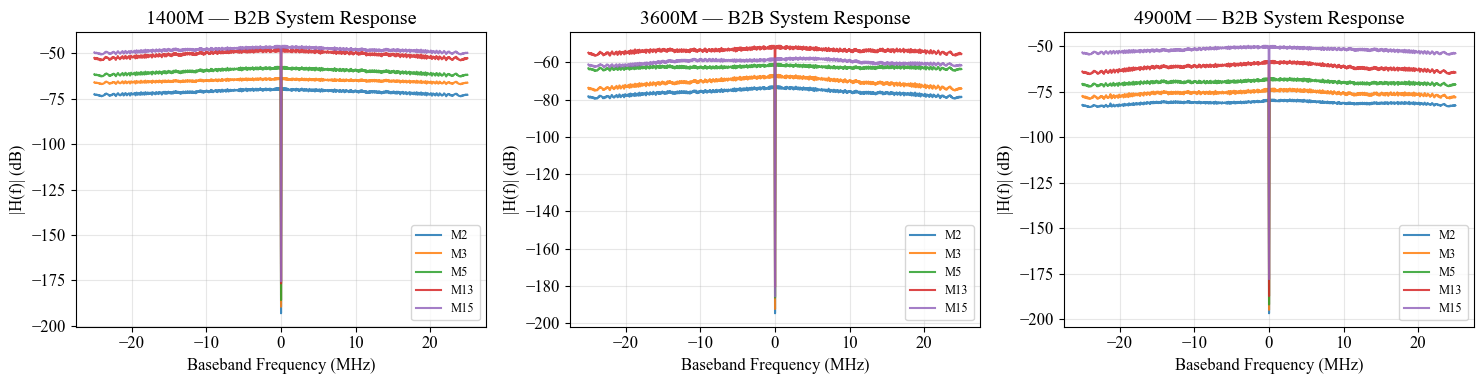

In [12]:
freq_axis_mhz = np.fft.fftshift(np.fft.fftfreq(U, d=1 / BW_HZ)) / 1e6

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, freq in zip(axes, ['1400M', '3600M', '4900M']):
    for m_val in M_ORDER:
        h_f = h_f_dict[freq].get(m_val)
        if h_f is None:
            continue
        H_db = 20 * np.log10(np.abs(np.fft.fftshift(h_f)) + 1e-10)
        ax.plot(freq_axis_mhz, H_db, label=m_val, alpha=0.85)
    ax.set_xlabel('Baseband Frequency (MHz)')
    ax.set_ylabel('|H(f)| (dB)')
    ax.set_title(f'{freq} — B2B System Response')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CALIB_B2B_HF_DIR / 'H_f_comparison.png', dpi=150)
plt.show()